## Reproduction note

This cleaned copy of the team's final analysis notebook has its saved cell outputs and machine-specific paths removed. Source imagery, rasters, and the LCZ reference map are not included. Place the inputs described in `data/README.md` under `data/`, then run this notebook from the repository root. The notebook has not been re-executed against the original data in this package.


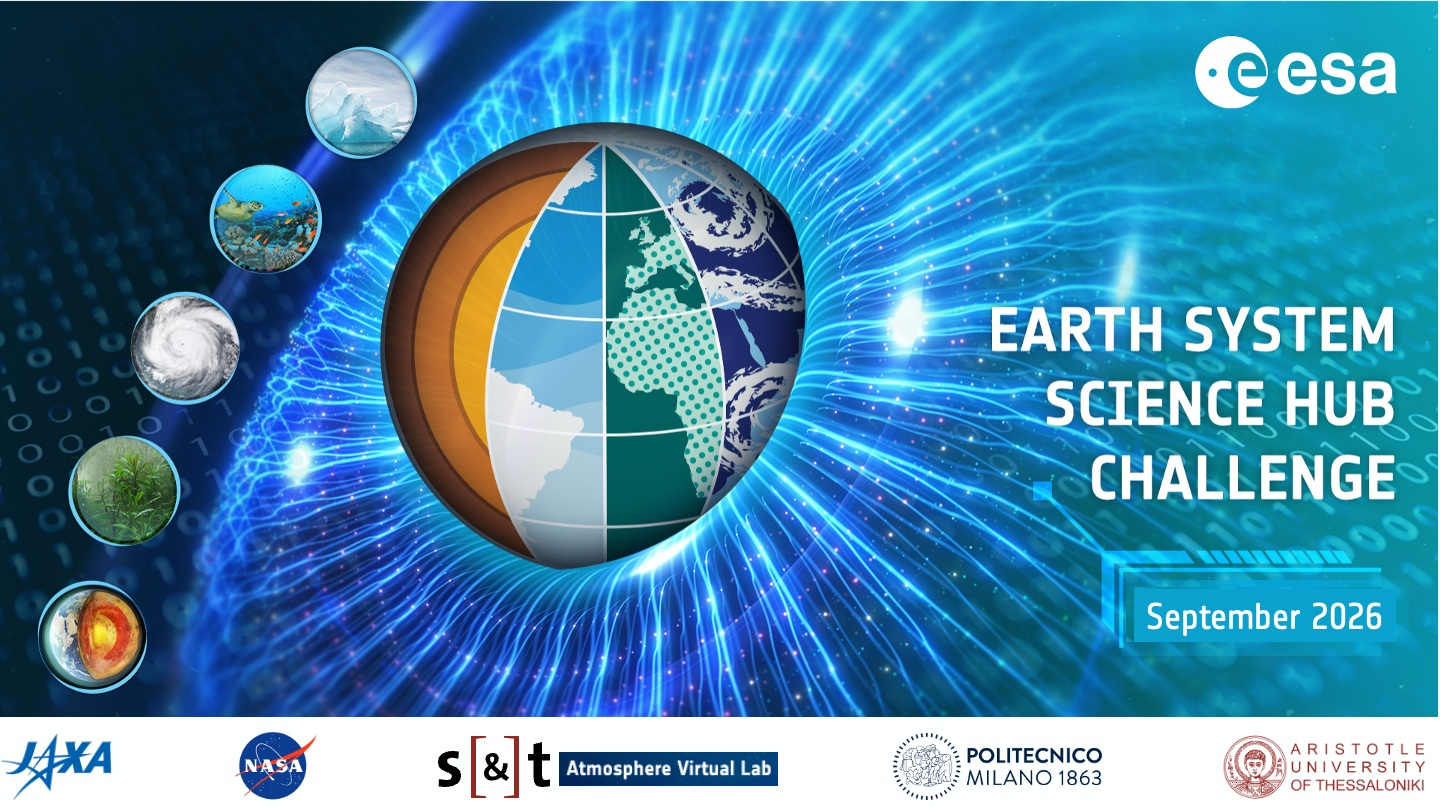

<div class="alert alert-info" role="alert">This concise notebook demonstrates guidelines for submission of your projects developed under the <b>Earth System Science Hub Challenge - 2026!</b><br>
Please use this notebook as a template for delivering your workflow with the code you used to produce the results! 
<br> 
</div>

# PART 1: SUMMARY

<hr>

# <a id='section1'></a><span style='color:DarkCyan'> Unsupervised Mapping of Urban Thermal Environments in the Milan and Monza-Brianza Area </center> </span>

**Authors:** Thomas Martinoli, Yiyi Cen, Sara Reffinetti <br>
**Team name:** Group 2A <br>
**Challenge:** Unsupervised characterisation of urban thermal environments <br>
<br>

# <a id='section2'></a><span style='color:DarkCyan'> 2. Description </center> </span>

### Description of research approach
This study focuses on the Milan and Monza-Brianza area in northern Italy and investigates whether distinct urban thermal environments can be identified directly from multi-variable Earth Observation data without defining the classes in advance.

The analysis covers summer 2021 (June–August) and combines Sentinel-2 spectral indices, Copernicus Tree Cover Density and Imperviousness Density, and Landsat 8 Land Surface Temperature. All variables were aligned to a common 100 m grid.

The workflow included data selection and compositing, spatial alignment, water masking, correlation analysis, normalization and Principal Component Analysis (PCA), followed by K-means clustering. Different clustering solutions (k = 4, 6 and 9) were then compared in terms of their spatial patterns and environmental characteristics. Finally, the resulting clusters were compared with the Global Local Climate Zone (LCZ) map to assess how the data-driven urban types relate to established urban climate classes.



# <a id='section3'></a><span style='color:DarkCyan'> 3. Table of Contents </center> </span> 

 1. [Title](#section1)
 2. [Description](#section2)
 3. [Table of Contents](#section3)
 4. [Import libraries](#section4)
 5. [Access dataset](#section5)
 6. [Analysis cells](#section6)
 7. [ Share the link to your webstory](#section7)

# PART 2: SCIENTIFIC EXPLOITATION AND ANALYSIS

<hr>

# <a id='section4'></a><span style='color:DarkCyan'> 4. Import Libraries </center> </span>

The libraries below are used for raster processing, tabular analysis, visualisation, PCA and K-means clustering.

In [ ]:
import os
import re
import glob
import json
import warnings
import tempfile
import xml.etree.ElementTree as ET
from pathlib import Path
from contextlib import ExitStack
from importlib.metadata import version
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from affine import Affine
from rasterio.crs import CRS
from rasterio.transform import from_origin
from rasterio.windows import Window, from_bounds
from rasterio.merge import merge
from rasterio.mask import mask as rio_mask
from rasterio.features import geometry_mask, rasterize
from rasterio.warp import reproject, transform_bounds, transform_geom
from rasterio.enums import Resampling
from shapely.geometry import box
from shapely.ops import unary_union
from scipy.ndimage import binary_dilation
from scipy.stats import chi2_contingency
from sklearn import config_context
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
    adjusted_rand_score, adjusted_mutual_info_score,
    normalized_mutual_info_score, homogeneity_completeness_v_measure)
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Patch
import plotly.graph_objects as go
from IPython.display import display

from pathlib import Path
import json

print({p: version(p) for p in ['numpy', 'rasterio', 'geopandas', 'scikit-learn']})

# <a id='section5'></a><span style='color:DarkCyan'> 5. Data sources </center> </span>
The Milan and Monza-Brianza area was selected because it includes a diverse mix of dense urban areas, suburban zones and vegetation, providing suitable spatial contrasts for the analysis. Summer 2021 (June–August) was chosen to represent warm-season conditions, while also ensuring the simultaneous availability of the main datasets used in the study.

| Datacube name | Variable name | Description | Reference | Region | Time range | Resolution |
|:--------------------:|:-----------------------:|:-------------:|:-----------------:|:-----------------:|:-----------------:|:-----------------:|
| Sentinel-2 MSI Level-2A | NDVI, NDRE, NDBI, BSI, MNDWI, Albedo | Spectral indices describing vegetation, built-up surfaces, bare soil, water and surface reflectivity. | <a href="https://documentation.dataspace.copernicus.eu/Data/Sentinel2.html" target="_blank">Copernicus Sentinel-2 Level-2A data</a> | Milan and Monza-Brianza, Italy | June–August 2021 | 20 m |
| Copernicus Tree Cover Density | Tree Cover Density (TCD) | Percentage of tree canopy cover. | <a href="https://land.copernicus.eu/en/products/high-resolution-layer-forests-and-tree-cover/tree-cover-density-2021-raster-10-m-100-m-europe-yearly" target="_blank">CLMS Tree Cover Density 2021</a> | Milan and Monza-Brianza, Italy | 2021 | 10 m |
| Copernicus Imperviousness Density | Imperviousness Density | Percentage of impervious and sealed surface cover. | <a href="https://land.copernicus.eu/en/products/high-resolution-layer-imperviousness/imperviousness-density-2021" target="_blank">CLMS Imperviousness Density 2021</a> | Milan and Monza-Brianza, Italy | 2021 | 10 m |
| Landsat 8 Collection 2 Level-2 | Land Surface Temperature (LST) | Land surface temperature used to describe urban thermal conditions. | <a href="https://www.usgs.gov/landsat-missions/landsat-collection-2-surface-temperature" target="_blank">USGS Landsat Collection 2 Surface Temperature</a> | Milan and Monza-Brianza, Italy | June–August 2021 | 30 m* |
| Global LCZ map | Local Climate Zones (LCZ) | Reference classification used to compare the data-driven clusters with established urban climate classes. | <a href="https://doi.org/10.5281/zenodo.6364594" target="_blank">Global Local Climate Zone map (Demuzere et al., 2022)</a> | Milan and Monza-Brianza, Italy | 2018 | 100 m |

\* Landsat 8 Collection 2 Level-2 LST is distributed at 30 m spatial resolution; the TIRS thermal band has a native resolution of 100 m.


# <a id='section6'></a><span style='color:DarkCyan'> 6. Analysis cells </center> </span>

The analysis follows the workflow below:

### Workflow

1. Data extraction and selection
2. Temporal compositing and spatial aggregation
3. Grid alignment and feature merging
4. Normalization
5. PCA
6. Clustering
7. Cluster interpretation
8. Comparison

The following sections describe each step of the workflow and include the code used to generate the final analysis-ready dataset and clustering results.


### Define input data and paths

This section defines the study-area boundary, the common 100 m feature stack and the output directory used for the analysis.

In [ ]:
REPO_ROOT = Path.cwd()
DATA_DIR = Path(os.environ.get("URBAN_THERMAL_DATA_DIR", REPO_ROOT / "data")).expanduser().resolve()
OUT_DIR = Path(os.environ.get("URBAN_THERMAL_OUTPUT_DIR", REPO_ROOT / "outputs")).expanduser().resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
AOI_PATH = DATA_DIR / "aoi/AOI_Milan_Monza.geojson"
STACK_OPTIONS = [
    DATA_DIR / "processed/FEATURES_JJA2021_100m_AOI_Milan_Monza.tif",
    DATA_DIR / "processed/FEATURES_JJA2021_100m_AOI_bbox.tif",
]
STACK = next((p for p in STACK_OPTIONS if p.exists()), None)
assert AOI_PATH.exists(), f"AOI not found: {AOI_PATH}. See data/README.md."
assert STACK is not None, f"Final 100 m feature stack not found under {DATA_DIR / 'processed'}. See data/README.md."
display(pd.Series({
    'Expected stack bands': 'NDVI, NDRE, NDBI, BSI, MNDWI, ALBEDO, TCD, Imperviousness, LST',
    'Sentinel-2 composite': 'June-August 2021 temporal median',
    'Common analysis grid': '100 m, EPSG:32632',
}))
print('Stack:', STACK)
print('AOI:', AOI_PATH)

### Inspect the common feature grid

The feature stack contains nine variables on the same 100 m grid. Its band names, CRS, resolution and basic value ranges are checked before analysis.

In [ ]:
EXPECTED = ['NDVI', 'NDRE', 'NDBI', 'BSI', 'MNDWI', 'ALBEDO', 'TCD', 'Imperviousness', 'LST']
ALIASES = {'TCD_mean_100m': 'TCD', 'Imperviousness_mean_100m': 'Imperviousness',
           'LST_mean_100m': 'LST', 'LST_median': 'LST'}

with rasterio.open(STACK) as src:
    values = src.read(masked=True).astype('float32').filled(np.nan)
    profile = src.profile.copy()
    descriptions = [ALIASES.get(d or f'b{i}', d or f'b{i}') for i, d in enumerate(src.descriptions, 1)]
    assert descriptions == EXPECTED, f'Unexpected bands: {descriptions}'
    assert src.crs.to_epsg() == 32632 and np.allclose(src.res, (100, 100))
    shape = values.shape[1:]

rows = []
for name, band in zip(EXPECTED, values):
    valid = np.isfinite(band)
    rows.append({'band': name, 'valid_%': 100 * valid.mean(),
                 'min': np.nanmin(band), 'median': np.nanmedian(band),
                 'mean': np.nanmean(band), 'max': np.nanmax(band)})
display(pd.DataFrame(rows).round(3))
print('Grid:', shape, 'CRS:', profile['crs'])

### Select valid analysis cells

The AOI mask is applied to the raster grid. Cells with incomplete data and open-water cells identified using MNDWI are excluded from the clustering analysis.

In [ ]:
data = {name: values[i] for i, name in enumerate(EXPECTED)}
aoi = gpd.read_file(AOI_PATH).to_crs(profile['crs'])
aoi_mask = rasterize([(geom, 1) for geom in aoi.geometry], out_shape=shape,
                     transform=profile['transform'], fill=0).astype(bool)
complete = np.all(np.isfinite(values), axis=0) & aoi_mask
water = data['MNDWI'] > 0.2
analysis_mask = complete & ~water
df = pd.DataFrame({name: data[name][analysis_mask] for name in EXPECTED})
print('Complete cells:', complete.sum())
print('Water cells excluded:', (complete & water).sum())
print('Cells used:', len(df))

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, name in zip(axes.flat, EXPECTED):
    ax.hist(df[name], bins=40, color='#2a9d8f', alpha=.85)
    ax.set_title(name)
    ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

### Scaling and principal component analysis

The variables are clipped at the 1st and 99th percentiles and rescaled to the 0–1 range. PCA is then used to summarise the main patterns of variation while retaining at least 90% of the total variance.

In [ ]:
FEATURES = [
    "NDVI", "NDRE", "NDBI", "BSI",
    "ALBEDO", "TCD", "Imperviousness", "LST"
]

clipped = df[FEATURES].clip(
    df[FEATURES].quantile(.01),
    df[FEATURES].quantile(.99),
    axis=1
)

span = (clipped.max() - clipped.min()).replace(0, np.nan)
scaled = ((clipped - clipped.min()) / span).fillna(0)

pca = PCA().fit(scaled)
ev = pca.explained_variance_ratio_
n_components = np.searchsorted(np.cumsum(ev), .90) + 1
X = PCA(n_components=n_components).fit_transform(scaled)

print("PC1 variance:", round(ev[0], 3))
print("Components for 90% variance:", n_components)

display(pd.DataFrame(
    pca.components_[:2].T,
    index=FEATURES,
    columns=["PC1", "PC2"]
).round(3))

### Compare candidate cluster numbers

K-means models with 4, 6 and 9 clusters are compared using the silhouette and Calinski–Harabasz scores. This provides a quantitative guide for selecting the final clustering solution.

In [ ]:
K_TEST = [4, 6, 9]
idx = np.random.default_rng(0).choice(
    len(X), min(20000, len(X)), replace=False
)

models, rows = {}, []

for k in K_TEST:
    model_k = KMeans(
        n_clusters=k,
        n_init=50,
        random_state=0
    ).fit(X)

    models[k] = model_k
    rows.append({
        "K": k,
        "silhouette": silhouette_score(
            X[idx], model_k.labels_[idx]
        ),
        "calinski": calinski_harabasz_score(
            X, model_k.labels_
        )
    })

scores = pd.DataFrame(rows).set_index("K")
display(scores.round(3))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

scores["silhouette"].plot(
    ax=ax[0], marker="o", grid=True
)
ax[0].set_title("Silhouette score")
ax[0].set_xlabel("K")

scores["calinski"].plot(
    ax=ax[1], marker="o", grid=True
)
ax[1].set_title("Calinski-Harabasz score")
ax[1].set_xlabel("K")

plt.tight_layout()
plt.show()

### Final K-means clustering

K-means models with K=4, K=6 and K=9 were all fitted and compared using clustering scores and their structure in PCA space. To keep the final presentation concise, the detailed cluster profiles and spatial map shown below focus on the selected K=4 solution, while the K=6 and K=9 results are retained for comparison.

In [ ]:
K = 4   # change to 6 or 9 if needed

model = models[K]
labels = model.labels_

cluster_map = np.full(shape, -1, dtype="int16")
cluster_map[analysis_mask] = labels

profile_norm = scaled.groupby(labels).mean()
profile_norm["cells"] = np.bincount(labels)
profile_norm["share_%"] = (
    100 * profile_norm["cells"] / len(labels)
)

display(profile_norm.round(3))

colors4 = ["#C9A227", "#7CB342", "#4A4A4A", "#1B5E20"]
colors6 = ["#6B4423", "#1B5E20", "#D9D9D9", "#C9A227", "#7CB342", "#4A4A4A"]
colors9 = ["#BDBDBD", "#90EE90", "#555555", "#006400", "#513205", "#C9A227", "#808080", "#9AB973", "#4B5320"]
cluster_colors = {
    4: colors4,
    6: colors6,
    9: colors9
}
colors = cluster_colors[K]

fig, ax = plt.subplots(figsize=(10, 4))
for c in range(K):
    ax.plot(
        FEATURES,
        profile_norm.loc[c, FEATURES],
        "o-",
        color=colors[c],
        label=f"C{c} ({profile_norm.loc[c, 'share_%']:.1f}%)"
    )

ax.set_ylabel("Mean normalised value (0–1)")
ax.set_title(f"Cluster profiles: K={K}")
ax.grid(alpha=.25)
ax.legend()
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

cmap = ListedColormap(colors)
masked_map = np.ma.masked_where(
    cluster_map < 0,
    cluster_map
)

plt.figure(figsize=(9, 8))
plt.imshow(
    masked_map,
    cmap=cmap,
    vmin=-.5,
    vmax=K-.5
)
plt.colorbar(
    ticks=range(K),
    label="Cluster"
)
plt.title(
    f"K={K} urban thermal environment clusters"
)
plt.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    1, len(K_TEST),
    figsize=(17,5),
    sharex=True,
    sharey=True
)

for ax, k in zip(axes, K_TEST):
    lab = models[k].labels_
    cmap = ListedColormap(
        cluster_colors[k]
    )

    ax.scatter(
        X[idx,0], X[idx,1],
        c=lab[idx],
        cmap=cmap,
        vmin=-.5,
        vmax=k-.5,
        s=5,
        alpha=.3,
        linewidths=0
    )

    centers = models[k].cluster_centers_
    ax.scatter(
        centers[:,0], centers[:,1],
        c=np.arange(k),
        cmap=cmap,
        vmin=-.5,
        vmax=k-.5,
        marker="X",
        s=130,
        edgecolor="black",
        linewidth=1
    )

    ax.set_title(f"K={k}")
    ax.set_xlabel(
        f"PC1 ({ev[0]*100:.1f}%)"
    )
    ax.grid(alpha=.25)

axes[0].set_ylabel(
    f"PC2 ({ev[1]*100:.1f}%)"
)

plt.suptitle(
    "Clustering structure in PCA space",
    y=1.02
)

plt.tight_layout()
plt.show()

### Comparison with Local Climate Zones

The final clusters are compared with the Global LCZ map on the same 100 m grid. A cross-tabulation, association metrics and a Sankey diagram are used to describe the relationship between the data-driven clusters and existing LCZ classes.

In [ ]:
# LCZ comparison + Sankey
LCZ_SOURCE_PATH = DATA_DIR / "external/lcz_filter_v1.tif"
LCZ_ALIGNED_PATH = OUT_DIR / "maps/LCZ_aligned_AOI.tif"
LCZ_ALIGNED_PATH.parent.mkdir(parents=True, exist_ok=True)

with rasterio.open(STACK) as ref:
    target_profile = ref.profile.copy()
    target_shape = (ref.height, ref.width)
    target_transform = ref.transform
    target_crs = ref.crs
    target_bounds = ref.bounds

if LCZ_ALIGNED_PATH.exists():
    with rasterio.open(LCZ_ALIGNED_PATH) as src:
        lcz = src.read(indexes=[1])[0]
        assert src.shape == target_shape
        assert src.transform == target_transform
else:
    assert LCZ_SOURCE_PATH.exists(), f"LCZ input not found: {LCZ_SOURCE_PATH}. See data/README.md."
    with rasterio.open(LCZ_SOURCE_PATH) as src:
        bounds = transform_bounds(
            target_crs, src.crs, *target_bounds
        )
        window = from_bounds(*bounds, src.transform)
        native = src.read(
            indexes=[1], window=window, masked=True
        )[0].filled(0).astype("uint8")

        lcz = np.zeros(target_shape, dtype="uint8")
        reproject(
            native, lcz,
            src_transform=src.window_transform(window),
            src_crs=src.crs,
            dst_transform=target_transform,
            dst_crs=target_crs,
            resampling=Resampling.nearest,
            src_nodata=0,
            dst_nodata=0,
        )

    out_profile = target_profile.copy()
    out_profile.update(
        count=1, dtype="uint8", nodata=0, compress="deflate"
    )
    with rasterio.open(LCZ_ALIGNED_PATH, "w", **out_profile) as dst:
        dst.write(lcz, 1)

valid = (
    analysis_mask
    & (cluster_map >= 0)
    & np.isin(lcz, np.arange(1, 18))
)

assert valid.any(), "No valid cells for LCZ comparison."

cross = pd.crosstab(
    pd.Series(cluster_map[valid], name="cluster"),
    pd.Series(lcz[valid], name="LCZ")
)
display(cross)

clusters = list(cross.index)
lcz_ids = list(cross.columns)

c_values = cluster_map[valid]
l_values = lcz[valid]

chi2, p_value, _, _ = chi2_contingency(cross)
cramers_v = np.sqrt(
    chi2 / (len(c_values) * (min(cross.shape) - 1))
)
h, completeness, v_measure = homogeneity_completeness_v_measure(
    l_values, c_values
)

display(pd.Series({
    "Cramer V": cramers_v,
    "Adjusted Rand": adjusted_rand_score(l_values, c_values),
    "Adjusted Mutual Info": adjusted_mutual_info_score(l_values, c_values),
    "Normalized Mutual Info": normalized_mutual_info_score(l_values, c_values),
    "Homogeneity": h,
    "Completeness": completeness,
    "V-measure": v_measure,
    "Chi-square p-value": p_value,
}).to_frame("value").round(3))

nodes = [f"C{i}" for i in clusters] + [
    f"LCZ {i}" for i in lcz_ids
]
sources, targets, values = [], [], []

for i, cluster in enumerate(clusters):
    for j, lcz_id in enumerate(lcz_ids):
        value = int(cross.loc[cluster, lcz_id])
        if value > 0:
            sources.append(i)
            targets.append(len(clusters) + j)
            values.append(value)

fig = go.Figure(go.Sankey(
    node=dict(label=nodes, pad=18, thickness=16),
    link=dict(source=sources, target=targets, value=values)
))

fig.update_layout(
    title="K-means clusters to LCZ",
    height=650
)
fig.show()

print("LCZ raster:", LCZ_ALIGNED_PATH)

### Cluster–LCZ correspondence matrices

Row-normalised matrices show the composition of each cluster in terms of LCZ classes for K=4, K=6 and K=9.

In [ ]:
# Cluster–LCZ correspondence matrices

LCZ_IDS = np.arange(1, 18)
FIG_PATH = OUT_DIR / "figures/cluster_lcz_correspondence_k4_k6_k9.png"

fig, axes = plt.subplots(
    1, len(K_TEST),
    figsize=(18, 4.5),
    constrained_layout=True
)

for ax, k in zip(axes, K_TEST):
    cluster_map_k = np.full(shape, -1, dtype="int16")
    cluster_map_k[analysis_mask] = models[k].labels_

    valid = analysis_mask & np.isin(lcz, LCZ_IDS)

    counts = pd.crosstab(
        pd.Series(cluster_map_k[valid], name="Cluster"),
        pd.Series(lcz[valid], name="LCZ")
    ).reindex(
        index=range(k),
        columns=LCZ_IDS,
        fill_value=0
    )

    percentages = counts.div(
        counts.sum(axis=1).replace(0, np.nan),
        axis=0
    ) * 100

    image = ax.imshow(
        percentages.to_numpy(),
        cmap="YlGnBu",
        vmin=0,
        vmax=100,
        aspect="auto"
    )

    ax.set_title(f"K={k}")
    ax.set_xlabel("LCZ class")
    ax.set_ylabel("Cluster")
    ax.set_xticks(range(17))
    ax.set_xticklabels(LCZ_IDS, rotation=45)
    ax.set_yticks(range(k))
    ax.set_yticklabels([f"C{i}" for i in range(k)])

fig.colorbar(
    image,
    ax=axes,
    label="Share within cluster (%)",
    shrink=0.85
)

fig.suptitle(
    "Normalised Cluster–LCZ correspondence matrices",
    fontsize=14
)

fig.savefig(
    FIG_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
print("Figure saved to:", FIG_PATH)

# PART 3: CREATE CAPTIVATING STORY

<hr>

In [ ]:
STORY_URL = "https://eoxhub-workspaces.github.io/preview-narratives/story/?storyurl=https://ESA-eodashboards.github.io/eodashboard-narratives/pr-preview/pr-196/2A.md"
print(STORY_URL)